### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no : 9

1 Use the inbuilt dataset 'titanic' as used in the above problem. Plot a box plot for distribution of age with respect to each gender along with the information about whether they survived or not. (Column names : 'sex' and 'age')
2 Write observations on the inference from the above statistics.


#age distribution by gender and survival in Titanic dataset

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display and style
pd.options.display.max_columns = None # Display all columns in DataFrame
sns.set(style='whitegrid', palette='Set2') # It is used to set the style and color of seaborn plots.”

In [2]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')

print('Dataset loaded successfully')
titanic.head()

Dataset loaded successfully


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Basic dataset information
print('Shape:', titanic.shape)
print('Size:', titanic.size)

print('\nInfo:')
titanic.info()

print('\nStatistical Summary:')
titanic.describe()

Shape: (891, 15)
Size: 13365

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Check missing values
print('Null counts before removal:')
titanic.isnull().sum()

Null counts before removal:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# Remove rows with missing important values
titanic_clean = titanic.dropna(subset=['survived', 'age', 'fare', 'embarked', 'embark_town']).reset_index(drop=True)

print('Shape after cleanup:', titanic_clean.shape)

print('\nNull counts after cleanup:')
titanic_clean[['survived', 'age', 'fare']].isnull().sum()

Shape after cleanup: (712, 15)

Null counts after cleanup:


survived    0
age         0
fare        0
dtype: int64

In [6]:
# Copy data
titanic_final = titanic_clean.copy()

# Age IQR
q1_age = titanic_final['age'].quantile(0.25)
q3_age = titanic_final['age'].quantile(0.75)
iqr_age = q3_age - q1_age

lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

# Fare IQR
q1_fare = titanic_final['fare'].quantile(0.25)
q3_fare = titanic_final['fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare

lower_fare = q1_fare - 1.5 * iqr_fare
upper_fare = q3_fare + 1.5 * iqr_fare

# Remove outliers
titanic_final = titanic_final[
    (titanic_final['age'] >= lower_age) & (titanic_final['age'] <= upper_age)
]

titanic_final = titanic_final[
    (titanic_final['fare'] >= lower_fare) & (titanic_final['fare'] <= upper_fare)
]

print('Shape after outlier cleanup:', titanic_final.shape)

Shape after outlier cleanup: (610, 15)


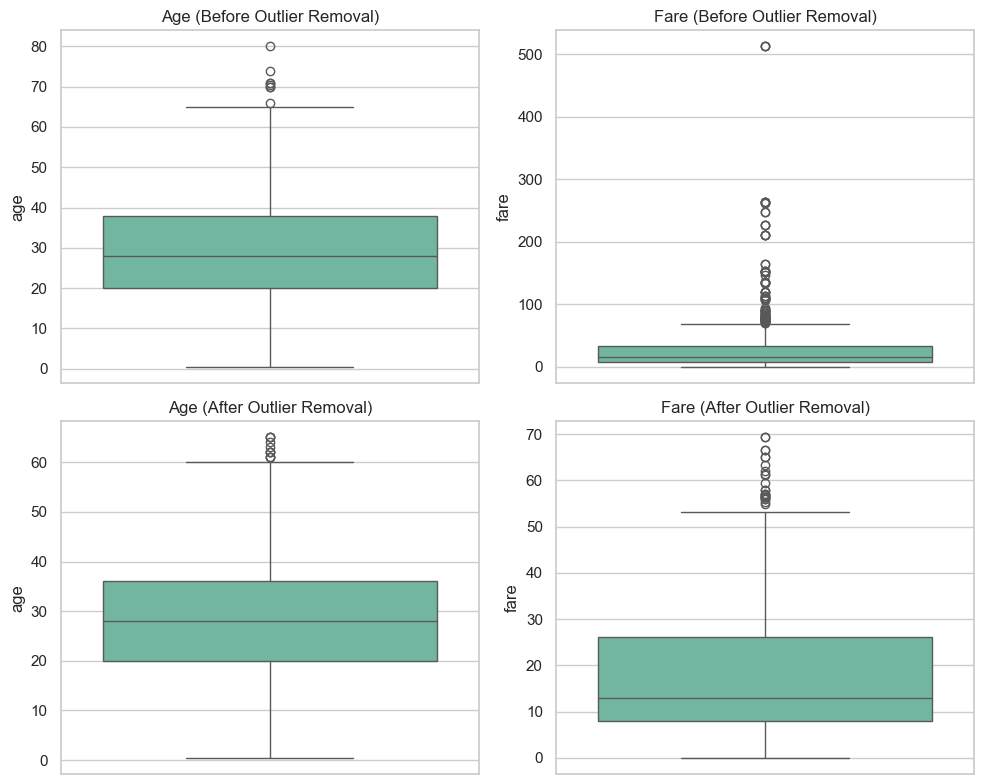

In [7]:
# Compare before and after outlier removal

plt.figure(figsize=(10, 8))

# Before
plt.subplot(2, 2, 1)
sns.boxplot(data=titanic_clean, y='age')
plt.title('Age (Before Outlier Removal)')

plt.subplot(2, 2, 2)
sns.boxplot(data=titanic_clean, y='fare')
plt.title('Fare (Before Outlier Removal)')

# After
plt.subplot(2, 2, 3)
sns.boxplot(data=titanic_final, y='age')
plt.title('Age (After Outlier Removal)')

plt.subplot(2, 2, 4)
sns.boxplot(data=titanic_final, y='fare')
plt.title('Fare (After Outlier Removal)')

plt.tight_layout()
plt.show()

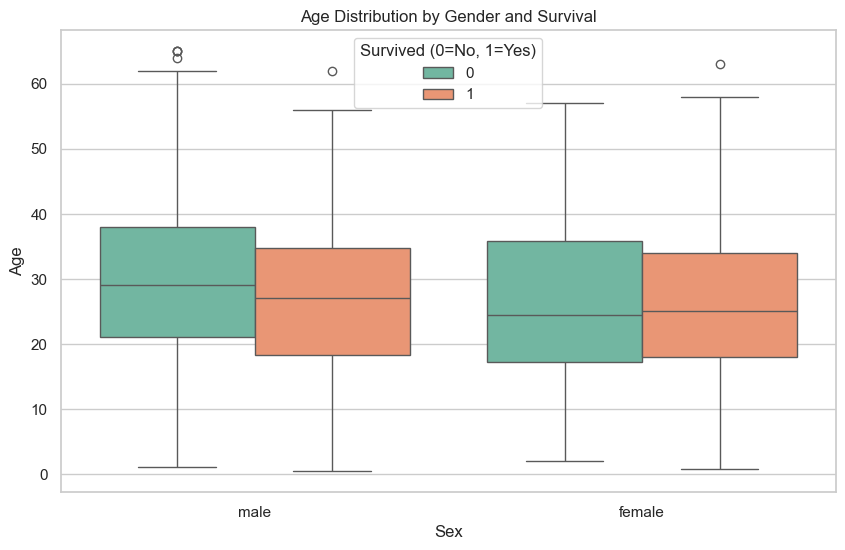

In [ ]:
# Age distribution by gender and survival

plt.figure(figsize=(10, 6))

sns.boxplot(data=titanic_final, x='sex', y='age', hue='survived')

plt.title('Age Distribution by Gender and Survival')
plt.xlabel('Sex')
plt.ylabel('Age')

plt.legend(title='Survived (0=No, 1=Yes)')

plt.show()

# Observations:
# 1. Females have higher survival rate than males
# 2. Children survived more than adults
# 3. Most male non-survivors are adults
# 4. Age distribution shows some outliers
# 5. Survival depends on both age and gender